In [1]:
pip install nltk scikit-learn matplotlib seaborn wordcloud pandas


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import nltk
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import PorterStemmer

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

import warnings
warnings.filterwarnings('ignore')

# Download NLTK data
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('punkt_tab')

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Admin\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Admin\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\Admin\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [5]:
data = {
    'review': [
        # Positive
        "I absolutely love this product! It works perfectly.",
        "Amazing quality, very happy with my purchase.",
        "Great service and fast delivery. Highly recommended!",
        "This is the best thing I have ever bought.",
        "Fantastic experience, will definitely buy again.",
        "The product exceeded my expectations. Really impressive!",
        "Wonderful item, great value for money.",
        "Super fast shipping and product looks exactly as described.",
        "Outstanding customer support and excellent product quality.",
        "Very satisfied with this purchase. Works like a charm.",

        # Negative
        "Terrible product. Stopped working after one day.",
        "Very disappointed. Not worth the money at all.",
        "Worst purchase I have ever made. Complete waste.",
        "Product broke immediately. Very poor quality.",
        "Awful experience. Customer service was rude and unhelpful.",
        "I hate this product. It never worked properly.",
        "Horrible quality, totally useless item.",
        "Do not buy this. It is a scam.",
        "Extremely bad. Returned it the next day.",
        "Disappointing and frustrating. Would not recommend.",

        # Neutral
        "The product is okay, nothing special.",
        "It works as expected. Average quality.",
        "Decent product for the price. Not amazing, not bad.",
        "Received the item on time. It is fine.",
        "The product is average. Does what it says.",
        "Neither good nor bad. Just a regular product.",
        "It arrived in good condition. Works normally.",
        "Fairly standard product. No complaints, no praise.",
        "The item is acceptable. Meets basic requirements.",
        "It does the job. Nothing extraordinary."
    ],
    'sentiment': [
        'positive','positive','positive','positive','positive',
        'positive','positive','positive','positive','positive',
        'negative','negative','negative','negative','negative',
        'negative','negative','negative','negative','negative',
        'neutral','neutral','neutral','neutral','neutral',
        'neutral','neutral','neutral','neutral','neutral'
    ]
}

df = pd.DataFrame(data)
print(f"Dataset Shape: {df.shape}")
print("\nSentiment Distribution:")
print(df['sentiment'].value_counts())
df.head(10)

Dataset Shape: (30, 2)

Sentiment Distribution:
sentiment
positive    10
negative    10
neutral     10
Name: count, dtype: int64


,review,sentiment
0,I absolutely love this product! It works perfe...,positive
1,"Amazing quality, very happy with my purchase.",positive
2,Great service and fast delivery. Highly recomm...,positive
3,This is the best thing I have ever bought.,positive
4,"Fantastic experience, will definitely buy again.",positive
5,The product exceeded my expectations. Really i...,positive
6,"Wonderful item, great value for money.",positive
7,Super fast shipping and product looks exactly ...,positive
8,Outstanding customer support and excellent pro...,positive
9,Very satisfied with this purchase. Works like ...,positive


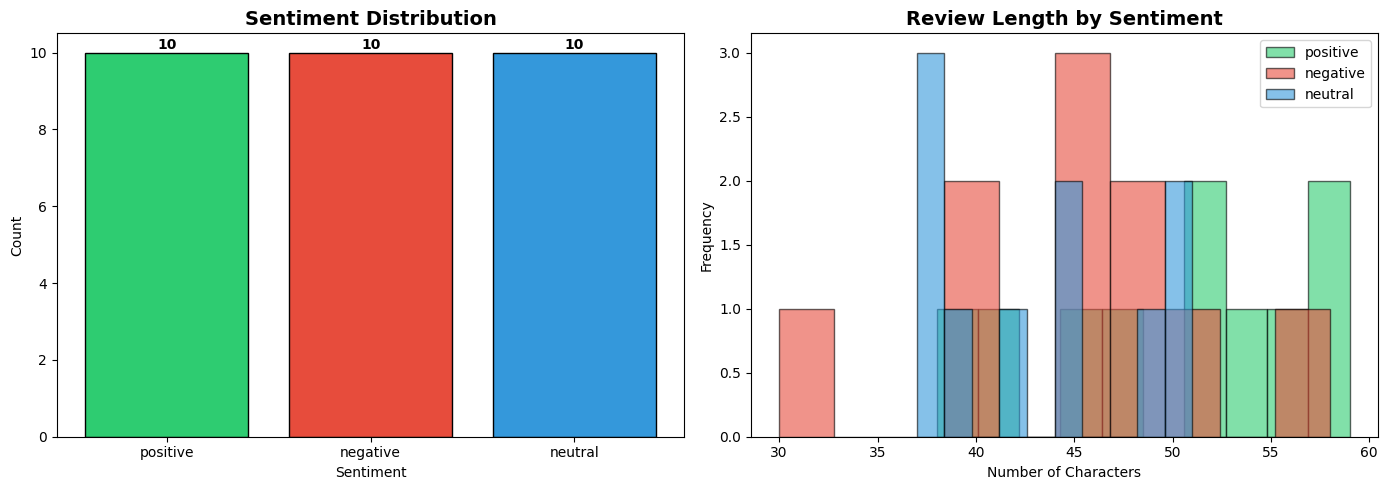

Average review length: 46.3


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart - sentiment count
colors = ['#2ecc71', '#e74c3c', '#3498db']
sentiment_counts = df['sentiment'].value_counts()
axes[0].bar(sentiment_counts.index, sentiment_counts.values, color=colors, edgecolor='black')
axes[0].set_title('Sentiment Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Sentiment')
axes[0].set_ylabel('Count')
for i, v in enumerate(sentiment_counts.values):
    axes[0].text(i, v + 0.1, str(v), ha='center', fontweight='bold')

# Histogram - review length
df['review_length'] = df['review'].apply(len)
for sentiment, color in zip(['positive', 'negative', 'neutral'], colors):
    subset = df[df['sentiment'] == sentiment]['review_length']
    axes[1].hist(subset, bins=10, alpha=0.6, label=sentiment, color=color, edgecolor='black')
axes[1].set_title('Review Length by Sentiment', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Number of Characters')
axes[1].set_ylabel('Frequency')
axes[1].legend()

plt.tight_layout()
plt.show()
print("Average review length:", round(df['review_length'].mean(), 2))

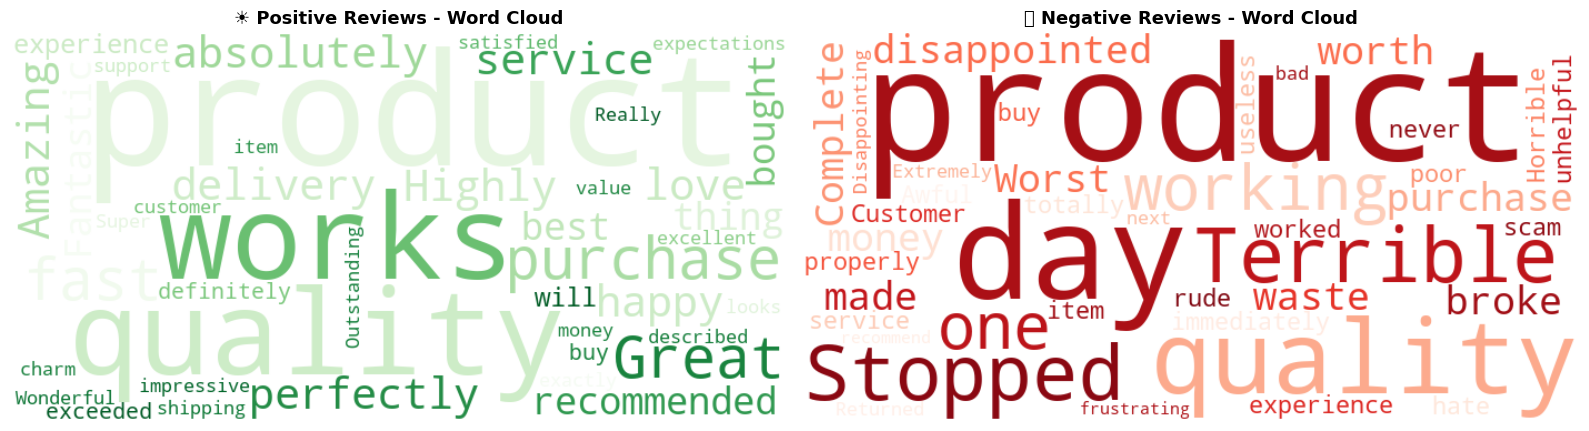

In [7]:
positive_text = ' '.join(df[df['sentiment'] == 'positive']['review'])
negative_text = ' '.join(df[df['sentiment'] == 'negative']['review'])

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

wc_pos = WordCloud(width=700, height=350, background_color='white',
                   colormap='Greens', max_words=50).generate(positive_text)
axes[0].imshow(wc_pos, interpolation='bilinear')
axes[0].axis('off')
axes[0].set_title('☀️ Positive Reviews - Word Cloud', fontsize=13, fontweight='bold')

wc_neg = WordCloud(width=700, height=350, background_color='white',
                   colormap='Reds', max_words=50).generate(negative_text)
axes[1].imshow(wc_neg, interpolation='bilinear')
axes[1].axis('off')
axes[1].set_title('🌧️ Negative Reviews - Word Cloud', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

In [8]:
stemmer = PorterStemmer()
stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    text = text.lower()                               # 1. Lowercase
    tokens = word_tokenize(text)                      # 2. Tokenize
    tokens = [t for t in tokens if t.isalpha()]       # 3. Remove punctuation/numbers
    tokens = [t for t in tokens if t not in stop_words]  # 4. Remove stopwords
    tokens = [stemmer.stem(t) for t in tokens]        # 5. Stemming
    return ' '.join(tokens)

df['cleaned_review'] = df['review'].apply(preprocess_text)

print("🔍 Preprocessing Example:")
print(f"Original : {df['review'][0]}")
print(f"Cleaned  : {df['cleaned_review'][0]}")

df[['review', 'cleaned_review', 'sentiment']].head(6)

🔍 Preprocessing Example:
Original : I absolutely love this product! It works perfectly.
Cleaned  : absolut love product work perfectli


,review,cleaned_review,sentiment
0,I absolutely love this product! It works perfe...,absolut love product work perfectli,positive
1,"Amazing quality, very happy with my purchase.",amaz qualiti happi purchas,positive
2,Great service and fast delivery. Highly recomm...,great servic fast deliveri highli recommend,positive
3,This is the best thing I have ever bought.,best thing ever bought,positive
4,"Fantastic experience, will definitely buy again.",fantast experi definit buy,positive
5,The product exceeded my expectations. Really i...,product exceed expect realli impress,positive


In [9]:
# Encode labels: positive=2, neutral=1, negative=0
label_map = {'positive': 2, 'neutral': 1, 'negative': 0}
df['label'] = df['sentiment'].map(label_map)

X = df['cleaned_review']
y = df['label']

# Train-Test Split (75% train, 25% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

# TF-IDF Vectorizer
tfidf = TfidfVectorizer(max_features=500, ngram_range=(1, 2))
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf  = tfidf.transform(X_test)

print(f"Training samples  : {X_train.shape[0]}")
print(f"Testing samples   : {X_test.shape[0]}")
print(f"TF-IDF Feature dim: {X_train_tfidf.shape[1]}")

Training samples  : 22
Testing samples   : 8
TF-IDF Feature dim: 162


In [10]:
models = {
    'Naive Bayes': MultinomialNB(),
    'Logistic Regression': LogisticRegression(max_iter=200, random_state=42)
}

results = {}
for name, model in models.items():
    model.fit(X_train_tfidf, y_train)
    preds = model.predict(X_test_tfidf)
    acc = accuracy_score(y_test, preds)
    results[name] = {'model': model, 'preds': preds, 'accuracy': acc}
    print(f"\n📌 {name}")
    print(f"   Accuracy: {acc*100:.1f}%")
    print(classification_report(y_test, preds, target_names=['negative','neutral','positive']))


📌 Naive Bayes
   Accuracy: 25.0%
              precision    recall  f1-score   support

    negative       0.17      0.50      0.25         2
     neutral       1.00      0.33      0.50         3
    positive       0.00      0.00      0.00         3

    accuracy                           0.25         8
   macro avg       0.39      0.28      0.25         8
weighted avg       0.42      0.25      0.25         8


📌 Logistic Regression
   Accuracy: 25.0%
              precision    recall  f1-score   support

    negative       0.17      0.50      0.25         2
     neutral       1.00      0.33      0.50         3
    positive       0.00      0.00      0.00         3

    accuracy                           0.25         8
   macro avg       0.39      0.28      0.25         8
weighted avg       0.42      0.25      0.25         8



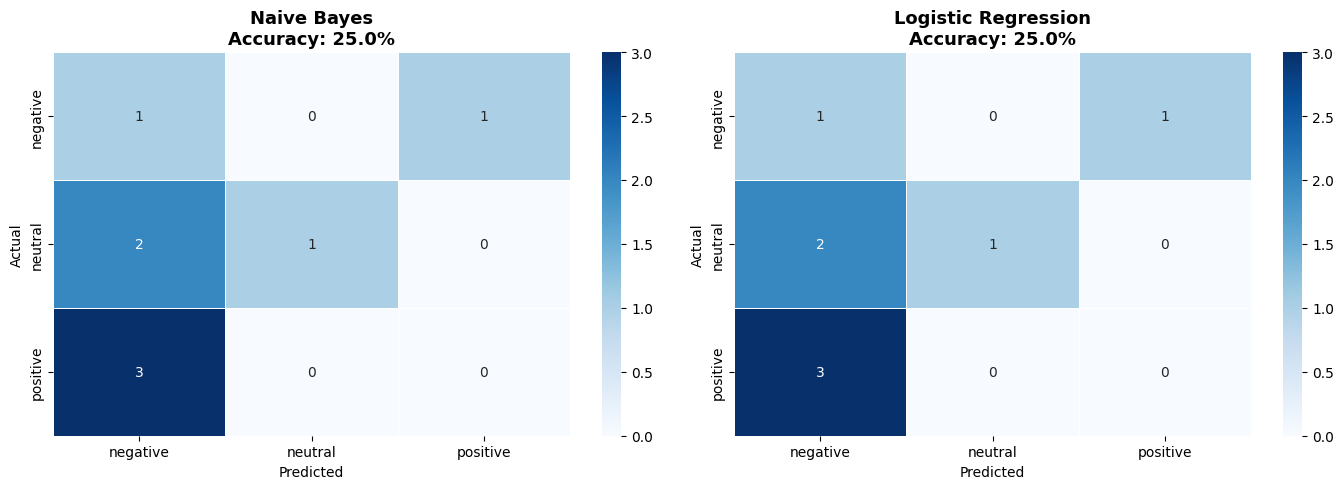

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
labels = ['negative', 'neutral', 'positive']

for ax, (name, res) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, res['preds'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=labels, yticklabels=labels, ax=ax,
                linewidths=0.5, linecolor='white')
    ax.set_title(f'{name}\nAccuracy: {res["accuracy"]*100:.1f}%', fontsize=13, fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.show()

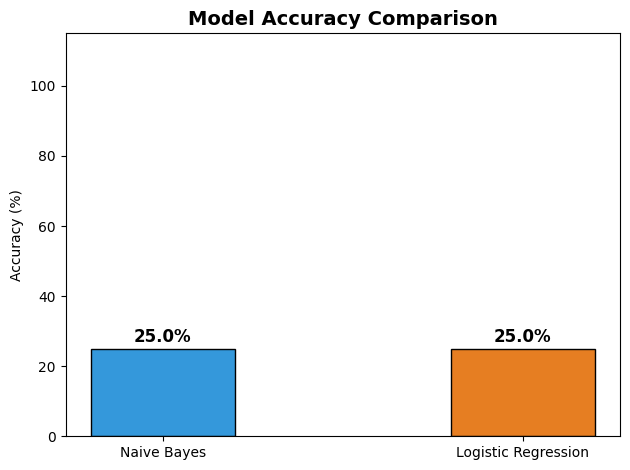


🏆 Best Model: Naive Bayes (25.0%)


In [12]:
names = list(results.keys())
accuracies = [res['accuracy'] * 100 for res in results.values()]

colors = ['#3498db', '#e67e22']
bars = plt.bar(names, accuracies, color=colors, width=0.4, edgecolor='black')
plt.ylim(0, 115)
plt.title('Model Accuracy Comparison', fontsize=14, fontweight='bold')
plt.ylabel('Accuracy (%)')
for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
             f'{acc:.1f}%', ha='center', fontweight='bold', fontsize=12)
plt.tight_layout()
plt.show()

best_model_name = max(results, key=lambda k: results[k]['accuracy'])
print(f"\n🏆 Best Model: {best_model_name} ({results[best_model_name]['accuracy']*100:.1f}%)")

In [13]:
reverse_label = {2: '😊 Positive', 1: '😐 Neutral', 0: '😠 Negative'}
best_model = results[best_model_name]['model']

def predict_sentiment(text):
    cleaned = preprocess_text(text)
    vector  = tfidf.transform([cleaned])
    pred    = best_model.predict(vector)[0]
    return reverse_label[pred]

# ✏️ Change these sentences and test!
test_sentences = [
    "This product is absolutely wonderful and I love it!",
    "It is okay, nothing great about it.",
    "Terrible quality. I want my money back.",
    "Decent product. Does what it is supposed to do.",
    "I am so happy with this purchase!"
]

print(f"Using model: {best_model_name}\n")
print(f"{'Review':<55} {'Predicted Sentiment'}")
print('-' * 75)
for sentence in test_sentences:
    print(f"{sentence:<55} {predict_sentiment(sentence)}")

Using model: Naive Bayes

Review                                                  Predicted Sentiment
---------------------------------------------------------------------------
This product is absolutely wonderful and I love it!     😊 Positive
It is okay, nothing great about it.                     😐 Neutral
Terrible quality. I want my money back.                 😠 Negative
Decent product. Does what it is supposed to do.         😠 Negative
I am so happy with this purchase!                       😠 Negative
